In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve

RS = 42

data = load_breast_cancer(as_frame=True)

X = data.data.copy()
y = data.target.copy()

print("Kuzatuvlar soni:", X.shape[0])
print("Featurelar soni:", X.shape[1])
print("Target nomlari:", list(data.target_names))
print("\nFeaturelarning dastlabki 10 tasi")
print(list(X.columns[:10]))

class_counts = y.value_counts().sort_index()
class_table = pd.DataFrame({
    "class_code": class_counts.index,
    "class_name": [data.target_names[i] for i in class_counts.index],
    "count": class_counts.values,
    "percentage": (class_counts.values / len(y) * 100).round(2)
})

class_table

Kuzatuvlar soni: 569
Featurelar soni: 30
Target nomlari: [np.str_('malignant'), np.str_('benign')]

Featurelarning dastlabki 10 tasi
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension']


,class_code,class_name,count,percentage
0,0,malignant,212,37.26
1,1,benign,357,62.74


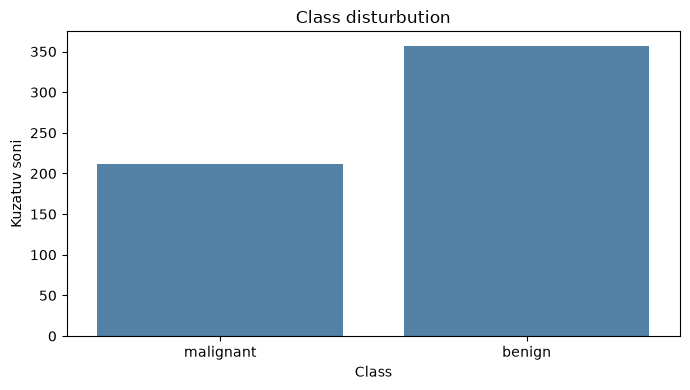

In [4]:
plt.figure(figsize=(7,4))
sns.countplot(x=y.map({0: "malignant", 1: "benign"}), color="steelblue")
plt.title("Class disturbution")
plt.xlabel("Class")
plt.ylabel("Kuzatuv soni")
plt.tight_layout()
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RS,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_train.shape)
print("y_train:", y_train.shape)
print("y_test :", y_train.shape)

print("\nTrain class disturbution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTest class disturbution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))



X_train: (455, 30)
X_test : (455, 30)
y_train: (455,)
y_test : (455,)

Train class disturbution:
target
0    0.374
1    0.626
Name: proportion, dtype: float64

Test class disturbution:
target
0    0.368
1    0.632
Name: proportion, dtype: float64


In [7]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:,1]

print("Decision Tree test bashorarlari")
print("Birinchi 10 ta bashorat:", dt_pred[:10])
# 

Decision Tree test bashorarlari
Birinchi 10 ta bashorat: [0 1 0 1 0 1 1 0 0 0]


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RS,
    # 
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:,1]

print("Random forest test bashorarlari tayyor")
print("Birinchi 10 ta bashorat:", rf_pred[:10])
# 

Random forest test bashorarlari tayyor
Birinchi 10 ta bashorat: [0 1 0 0 0 1 1 0 0 0]


In [13]:
gb = GradientBoostingClassifier(
    random_state=RS
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:,1]

print("Gradient boosting test bashorarlari tayyor")
print("Birinchi 10 ta bashorat:", gb_pred[:10])
# 

Gradient boosting test bashorarlari tayyor
Birinchi 10 ta bashorat: [0 1 0 0 0 1 1 0 0 0]


In [15]:
models = {
    "Decision Tree": (dt_pred, dt_proba),
    "Random Forest": (rf_pred, rf_proba),
    "Gradient Boosting": (gb_pred, gb_proba)
}

rows = []
for name, (pred, proba) in models.items():
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, pred),
    })

results_df = pd.DataFrame(rows).set_index("Model").round(4)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Decision Tree,0.9123,0.9559,0.9028,0.9286,0.9157
Random Forest,0.9561,0.9589,0.9722,0.9655,0.9504
Gradient Boosting,0.9561,0.9467,0.9861,0.9660,0.9454


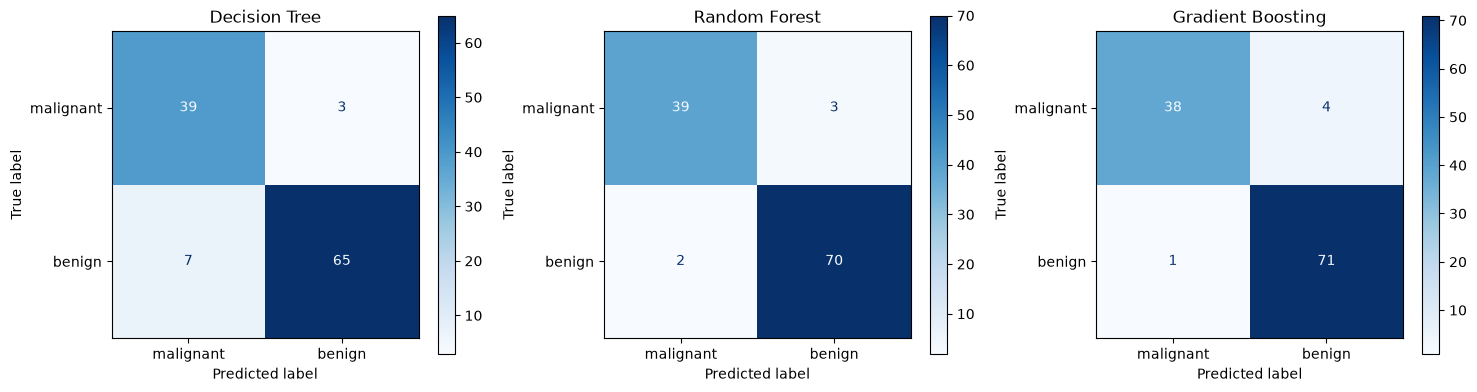

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred,
        display_labels=data.target_names,
        cmap="Blues",
        ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

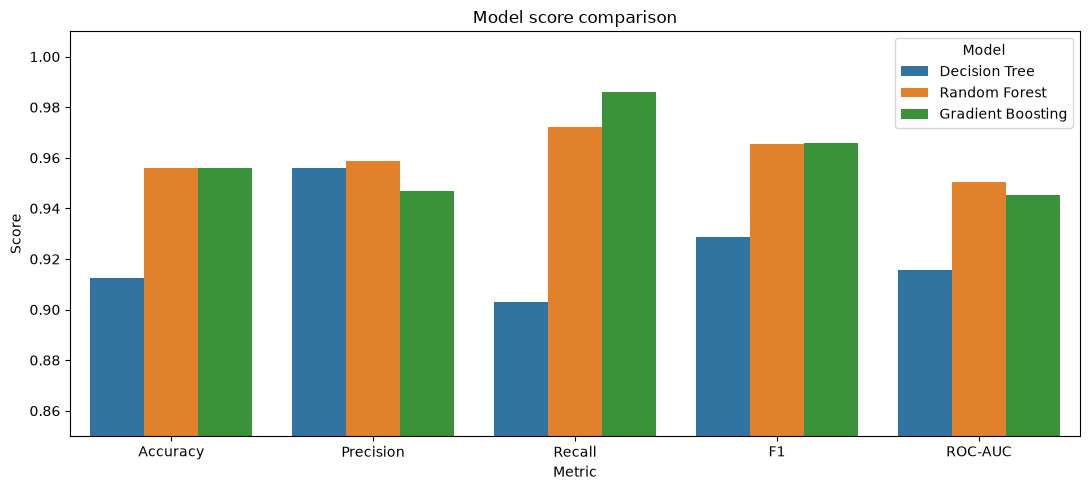

In [22]:
plot_df = results_df.reset_index().melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
plt.ylim(0.85, 1.01)
plt.title("Model score comparison")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()

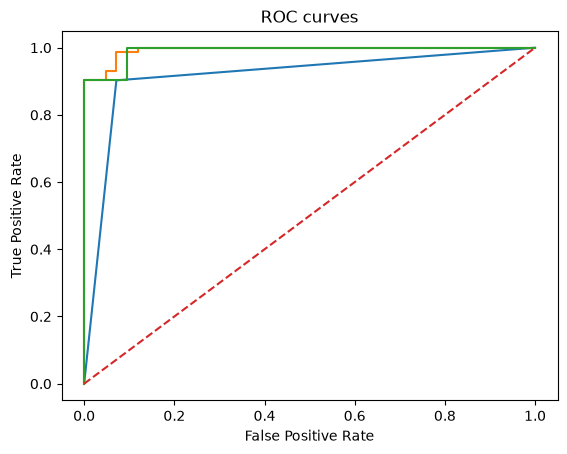

In [25]:
plt.Figure(figsize=(8, 6))
for name, (_,proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")


plt.plot([0,1],[0,1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.show()